The two cells in this notebook produce the Figs. 15,16,17 in appendix C

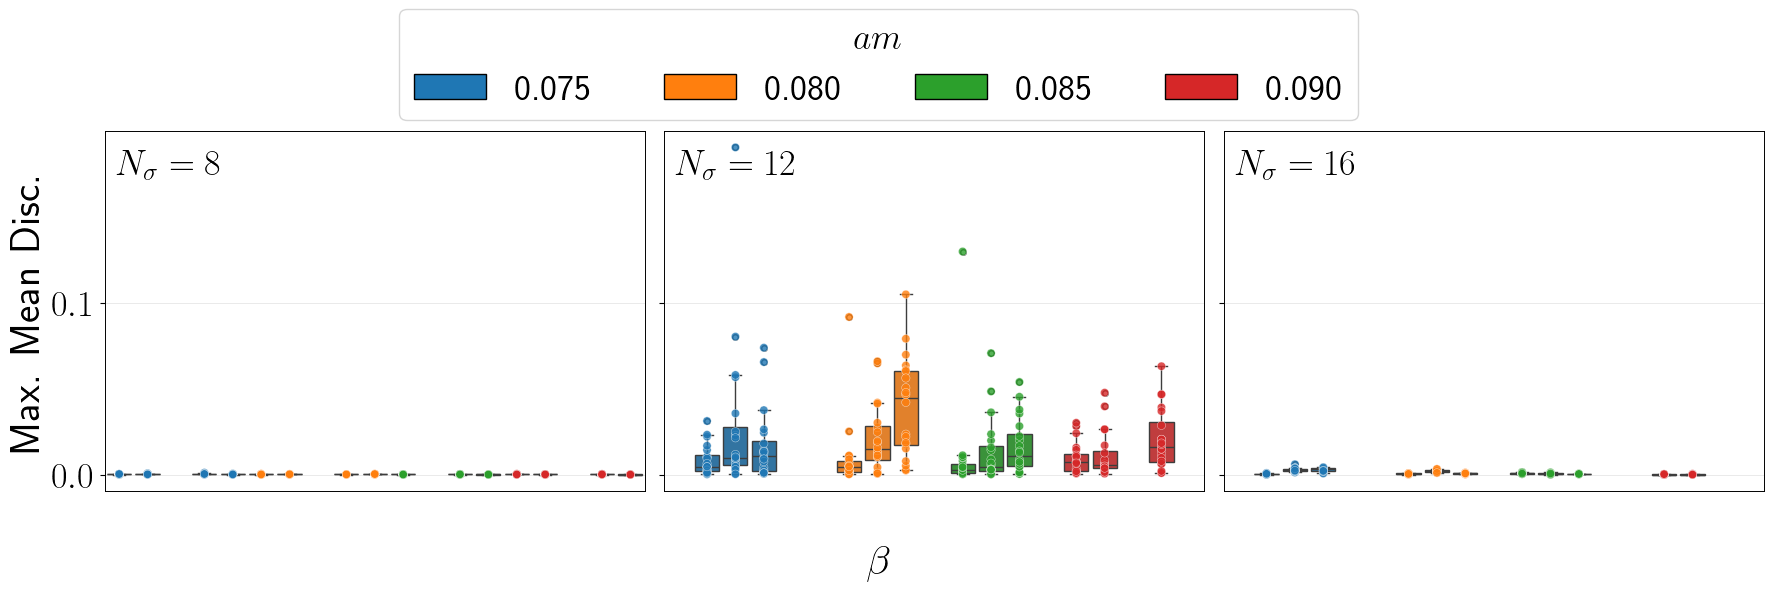

In [ ]:
#This plotting scripts were improved using LLMs.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

plt.rcParams["text.usetex"] = True

runsU = 21 #adjust based on number of runs in csv (1-based indexing)
mmd_df = pd.read_csv("/path/to/file/mmd_densitycomp_results_made8_remV12_2048.csv")
mmd_df.columns = ["vol", "mass", "beta", "mmd_mean", "mmd_std"] + [f"mmd_run{i}" for i in range(1, runsU)]

mmd_df["mass_beta"] = mmd_df.apply(lambda row: f"{row['mass']:.3f}, {row['beta']:.3f}", axis=1)

melted = mmd_df.melt(
    id_vars=["vol", "mass_beta"],
    value_vars=[f"mmd_run{i}" for i in range(1, runsU)],
    var_name="run",
    value_name="mmd"
)

def plot_three_volumes(melted, volumes=(8, 12, 16), mass_order=None):
    df = melted.copy()

    if not {"mass", "beta"}.issubset(df.columns):
        df[["mass", "beta"]] = df["mass_beta"].str.split(",", expand=True).astype(float)

    df["vol"] = df["vol"].astype(float)

    if mass_order is None:
        mass_order = [0.075, 0.080, 0.085, 0.090]

    palette_list = sns.color_palette("tab10", n_colors=len(mass_order))
    mass_to_color = {m: c for m, c in zip(mass_order, palette_list)}

    df_sel = df[df["vol"].isin([float(v) for v in volumes])].copy()
    if df_sel.empty:
        raise ValueError(f"No data found for volumes={volumes}. Available: {sorted(df['vol'].unique())}")

    beta_order = sorted(df_sel["beta"].unique())

    desired_betas = [4.98, 5.0]
    tick_positions = [beta_order.index(b) for b in desired_betas if b in beta_order]
    tick_labels = [rf"{b:.2f}" for b in desired_betas if b in beta_order]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for ax, vol_selected in zip(axes, volumes):
        dfv = df_sel[df_sel["vol"] == float(vol_selected)].copy()

        sns.boxplot(
            data=dfv,
            x="beta", y="mmd",
            hue="mass",
            order=beta_order,
            hue_order=mass_order,
            palette=mass_to_color,
            width=0.85,
            fliersize=4,
            ax=ax,
        )

        sns.stripplot(
            data=dfv,
            x="beta", y="mmd",
            hue="mass",
            order=beta_order,
            hue_order=mass_order,
            palette=mass_to_color,
            dodge=False,
            jitter=0.0,
            size=6,
            alpha=0.8,
            linewidth=0.3,
            edgecolor="white",
            ax=ax,
        )

        # Only show ticks for 4.98 and 5.00
        ax.set_xticks([])
        ax.set_xticklabels([])

        # Remove seaborn legend from each axis
        if ax.legend_ is not None:
            ax.legend_.remove()

        ax.set_xlabel("")

        ax.text(
            0.02, 0.95, rf"$N_\sigma = {int(float(vol_selected))}$",
            transform=ax.transAxes, ha="left", va="top",
            fontsize=26, fontweight="bold"
        )

        for lbl in ax.get_xticklabels():
            lbl.set_rotation(0)
            lbl.set_horizontalalignment("right")

        ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.6)
        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_linewidth(0.7)

        #ax.tick_params(axis="x", labelsize=26)
        ax.tick_params(axis="y", labelsize=26)

    sy = axes[0].set_ylabel("Max. Mean Disc.", fontsize=30)
    for ax in axes[1:]:
        ax.set_ylabel("")

    sx = fig.supxlabel(r'$\beta$', fontsize=30, y=0.07)

    # One shared legend
    handles = [Patch(facecolor=mass_to_color[m], edgecolor="k", label=f"{m:.3f}") for m in mass_order]
    leg = fig.legend(
        handles=handles,
        title=r"$am$",
        fontsize=26,
        title_fontsize=26,
        loc="upper center",
        ncols=len(mass_order),
        frameon=True,
        bbox_to_anchor=(0.5, 1.25),
    )

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.25)
    fig.savefig(
        "mmd_intervol.pdf",
        bbox_inches="tight",
        pad_inches=0.02,
        bbox_extra_artists=(leg,sy)
    )
    plt.show()

# Example usage:
plot_three_volumes(melted, volumes=(8, 12, 16), mass_order=[0.075, 0.080, 0.085, 0.090])

Cumulant plots

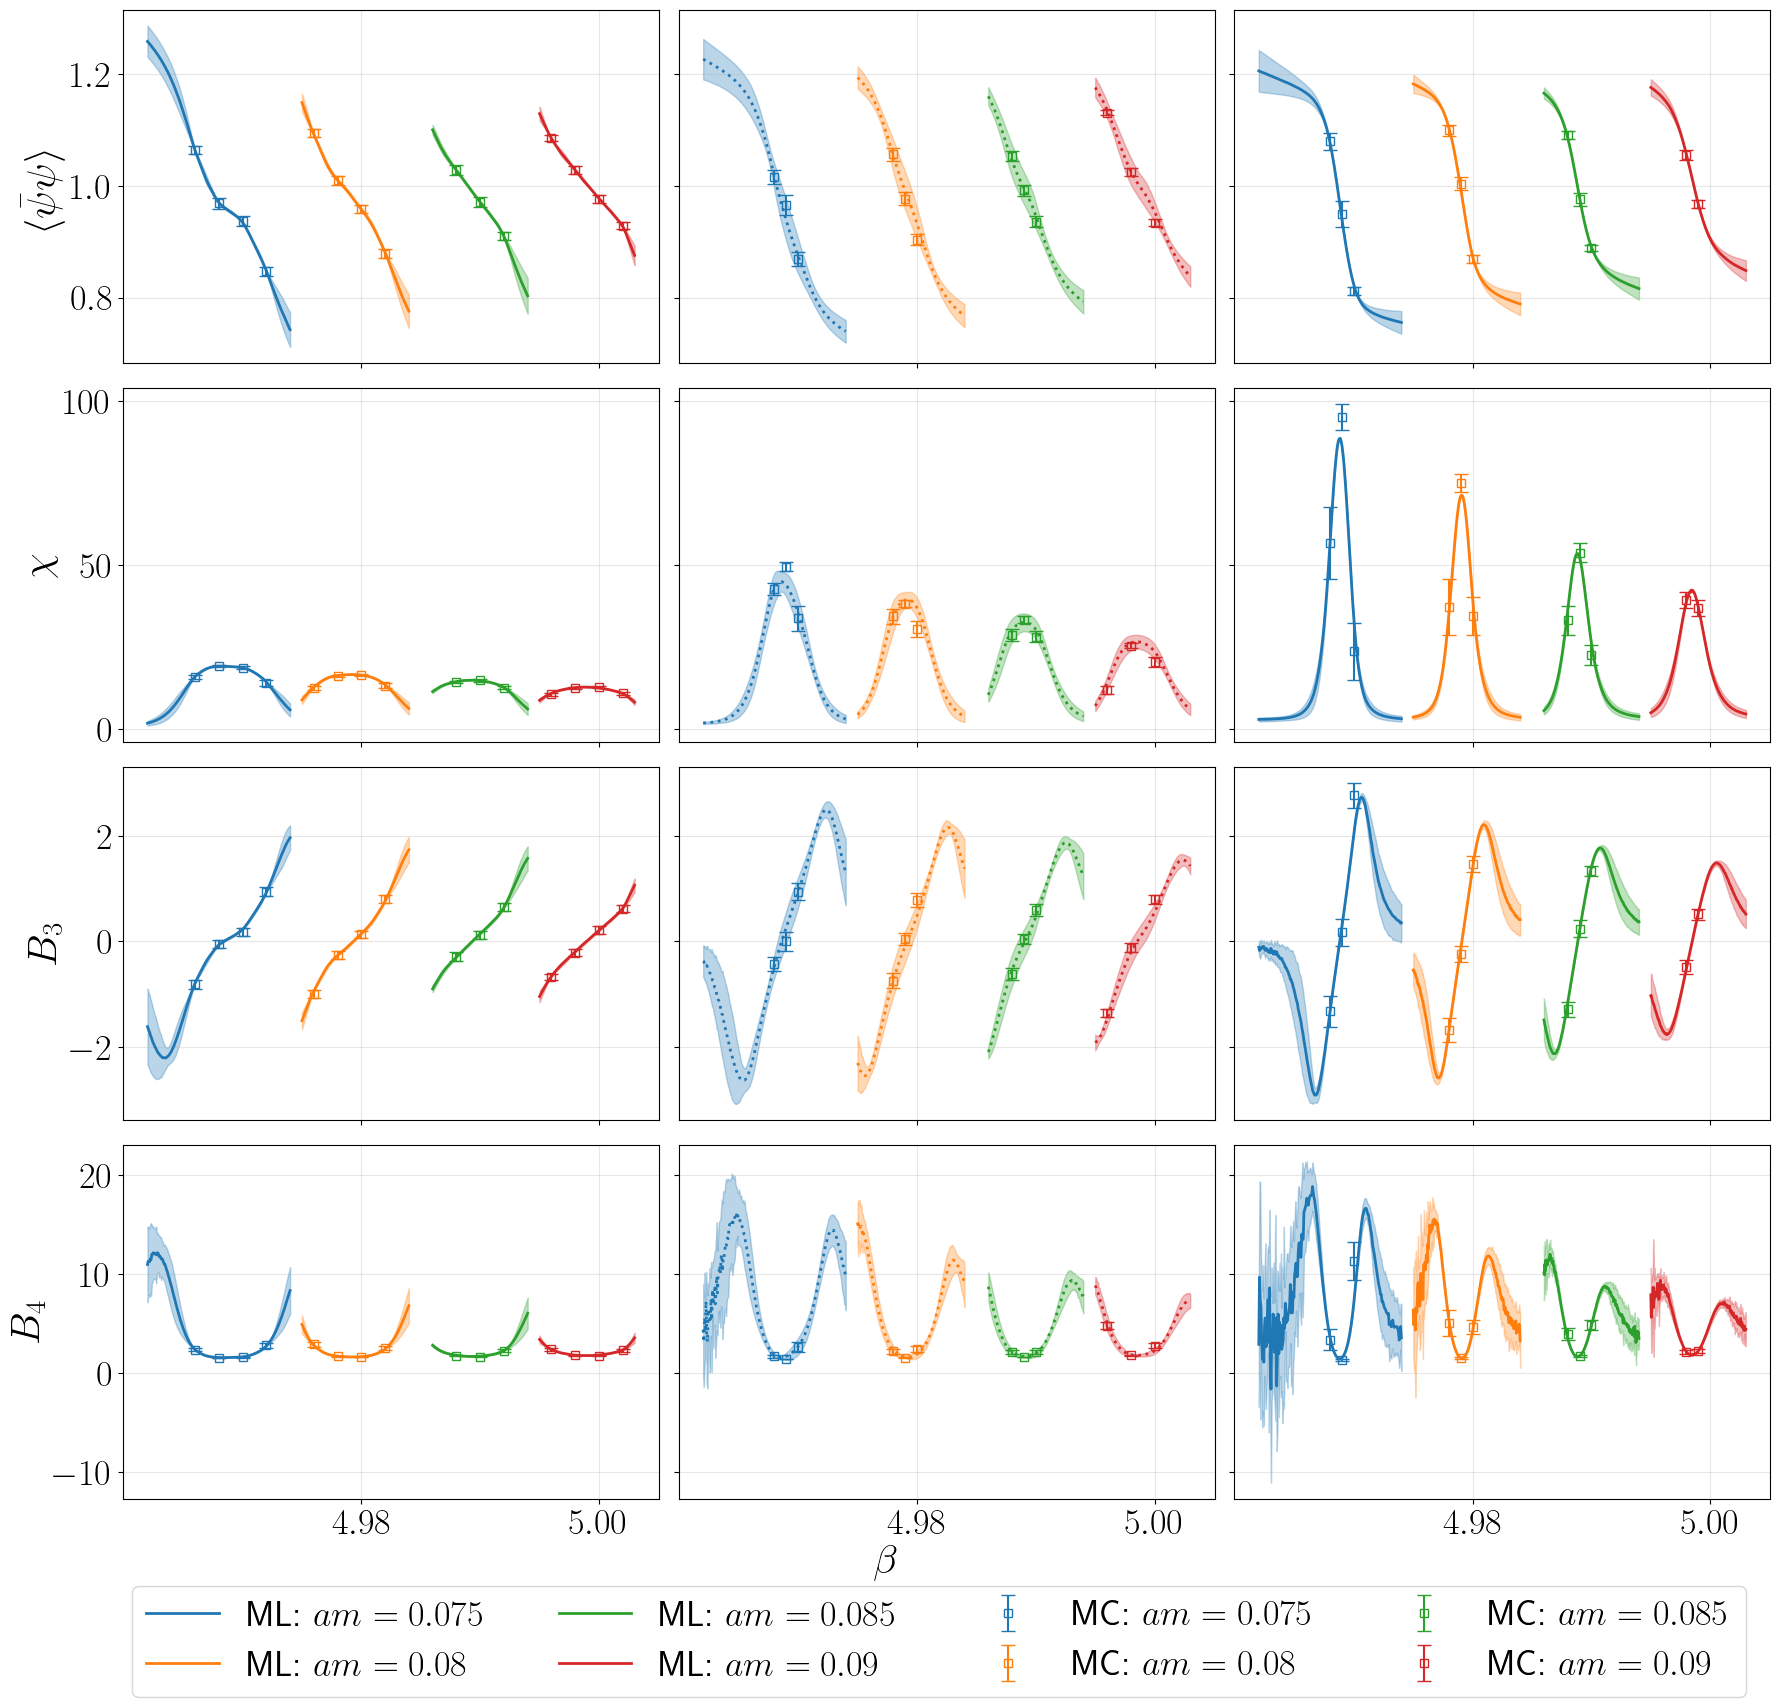

In [ ]:
#This plotting scripts were improved using LLMs.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True

def make_4x3_observable_volume_plot(dataset_folder, volumes):
    """
    Make a 4x3 grid plot where:
    - Rows: observables (chi, sus, B3, B4)
    - Columns: specified volumes
    Includes averaging over ML runs with mean and std deviation.
    """
    
    # ---------------- Fixed paths and constants ----------------
    base_path = "/Users/simransingh/PaperPlots/Nt4"
    ml_values = ["0.075", "0.08", "0.085", "0.09"]
    ml_folder_names = [f"run{i}" for i in range(11, 21)]
    
    # Observable dictionary with proper column indices
    observables = ['chi', 'sus', 'B3', 'B4']
    dic_obs = {'chi': 2, 'sus': 4, 'B3': 6, 'B4': 8}
    
    ff_files = {
        "0.075": os.path.join(base_path, "ffd_cumulants_Nt4_m075.dat"),
        "0.08": os.path.join(base_path, "ffd_cumulants_Nt4_m080.dat"),
        "0.085": os.path.join(base_path, "ffd_cumulants_Nt4_m085.dat"),
        "0.09": os.path.join(base_path, "ffd_cumulants_Nt4_m090.dat")
    }

    # Color cycle per ml
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    mass_colors = {mass: color_cycle[i % len(color_cycle)] for i, mass in enumerate(ml_values)}

    # ---------------- Helpers ----------------
    def extract_run_label(folder):
        return os.path.basename(folder.strip('/'))

    def load_ml_files(folder):
        """Load Nf5_ml*.dat files from one ML folder."""
        data_frames = []
        label = extract_run_label(folder)
        for ml in ml_values:
            filepath = os.path.join(folder, f"Nf5_ml{ml}.dat")
            if os.path.exists(filepath):
                df = pd.read_csv(filepath, sep=r'\s+', header=None)
                df.columns = ['Ns', 'mass', 'beta', 'chi', 'sus', 'B3', 'B4', 'std']
                df['ml'] = float(ml)
                df['run'] = label
                df['sus'] *= df['Ns']**3  # scale susceptibility by volume
                data_frames.append(df)
        return pd.concat(data_frames, ignore_index=True) if data_frames else None

    def load_ff(filepath, col):
        """Load Frankfurt .dat file into DataFrame."""
        data = np.loadtxt(filepath, skiprows=1, usecols=(0, 1, col, col+1))
        df = pd.DataFrame(data, columns=['vol', 'beta', 'mean', 'err'])
        if col == dic_obs['sus']:  # Scale susceptibility by volume
            df['mean'] *= df['vol']**3
            df['err']  *= df['vol']**3
        return df

    def plot_line_bar(ax, df, clr, label, linestyle="-"):
        df_sorted = df.sort_values('beta').reset_index(drop=True)
        x = df_sorted['beta']
        y = df_sorted['mean']
        e = df_sorted['error']
        ax.plot(x, y, label=label, color=clr, linestyle=linestyle, linewidth=2)
        ax.fill_between(x, y - e, y + e, color=clr, alpha=0.3)

    # ---------------- Load ML data ----------------
    dataset_path = os.path.join(base_path, dataset_folder)
    folders = [os.path.join(dataset_path, name) for name in ml_folder_names]
    all_data = [load_ml_files(folder) for folder in folders]
    ml_all = pd.concat([df for df in all_data if df is not None], ignore_index=True)

    # ---------------- Compute mean and std per (ml, Ns, beta, observable) ----------------
    results = []
    beta_values = sorted(ml_all['beta'].unique())
    
    for obs in observables:
        for Ns_value in volumes:
            for ml in map(float, ml_values):
                for beta in beta_values:
                    df_sub = ml_all.query("ml == @ml and Ns == @Ns_value and beta == @beta")
                    observable_values = df_sub[obs].values
                    if len(observable_values) < 2:
                        continue
                    mean_val = np.mean(observable_values)
                    err_std = np.std(observable_values, ddof=1)
                    results.append({
                        'observable': obs, 
                        'Ns': Ns_value, 
                        'ml': ml, 
                        'beta': beta,
                        'mean': mean_val, 
                        'error': err_std
                    })

    df_result = pd.DataFrame(results).sort_values(['observable', 'Ns', 'ml', 'beta'])

    # ---------------- Create 4x4 subplot grid ----------------
    #figsize=(5 * len(volumes), 16)
    fig, axes = plt.subplots(
        4, len(volumes),  # 4 rows (observables) x N columns (volumes)
        figsize=(18, 16),  
        sharex=True, sharey='row',  
        squeeze=True
    )


    ylabels = {
        'chi': r'$\langle \bar{\psi} \psi \rangle$',
        'sus': r'$\chi$', 
        'B3': r'$B_3$',
        'B4': r'$B_4$'
    }

    legend_handles, legend_labels = None, None
    
    for row_idx, obs in enumerate(observables):
        for col_idx, volume in enumerate(volumes):
            ax = axes[row_idx, col_idx]
            
            # Load Frankfurt data for this volume and observable
            ff_data = {}
            for ml in ml_values:
                if ml in ff_files and os.path.exists(ff_files[ml]):
                    ff_df = load_ff(ff_files[ml], dic_obs[obs])
                    ff_volume_data = ff_df[ff_df["vol"] == volume]
                    if not ff_volume_data.empty:
                        ff_data[ml] = ff_volume_data
            
            # Plot Frankfurt data
            for ml in ff_data:
                df_ff = ff_data[ml]
                ax.errorbar(
                    df_ff['beta'], df_ff['mean'], yerr=df_ff['err'],
                    fmt='s', label=f"MC: $am= {ml}$",
                    capsize=5, markersize=6, markerfacecolor='none'
                )
            tol=1e-6
            # Plot ML averaged data
            for ml_str in ml_values:
                ml = float(ml_str)
                df_ml = df_result.query("observable == @obs and ml == @ml and Ns == @volume")
                if not df_ml.empty:
                    #when we use the vol interpolated data for visualization purposes, we want to distinguish it with a different linestyle
                    #This is also done for the mass interpolated data, 
                    if np.isclose(volume,12,tol):
                        plot_line_bar(ax, df_ml, clr=mass_colors[ml_str], 
                                    label=f"ML: $am= {ml_str}$", linestyle=":")
                    else:
                        plot_line_bar(ax, df_ml, clr=mass_colors[ml_str], 
                                    label=f"ML: $am= {ml}$")
            
            
            if col_idx == 0:  
                ax.set_ylabel(ylabels[obs], fontsize=30)
            
            fig.supxlabel(r'$\beta$', fontsize=30, y=0.009)
            if volume == 12:
                current_ticks = ax.get_xticks()
                new_ticks = [tick for tick in current_ticks if not np.isclose(tick, 4.95, atol=0.01)]
                ax.set_xticks(new_ticks)
            
            ax.tick_params(axis='both', labelsize=26)
            ax.grid(True, alpha=0.3)
            
            if legend_handles is None or legend_labels is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

    # ---------------- Global legend ----------------
    if legend_handles and legend_labels:
        fig.legend(legend_handles, legend_labels, 
                  loc='upper center', 
                  bbox_to_anchor=(0.53, 0.017),  
                  ncol=4,  
                  fontsize=26,
                  frameon=True)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.06)  # Make room for the legend
    
    # Save plot if needed
    outname = f"Nt4_4x3_observables_volumes_volInt_1120.pdf"
    plt.savefig(outname, bbox_inches='tight',pad_inches=0.02)
    
    plt.show()

    return df_result

# Example usage 
volumes_to_plot = [8,12,16]  # Modify this list with your desired volumes
#The reader can generate the folder below using the eval_Maf_cumulant.py files provided in the repo
df_test = make_4x3_observable_volume_plot("Nt4_cumulants_remV12_2048_made8", volumes_to_plot)